Cluster assignment counts (No Scaling):
Cluster_No_Scaling
0    518
1    131
Name: count, dtype: int64

Cluster assignment counts (With Scaling):
Cluster_Scaled
0    368
1    281
Name: count, dtype: int64


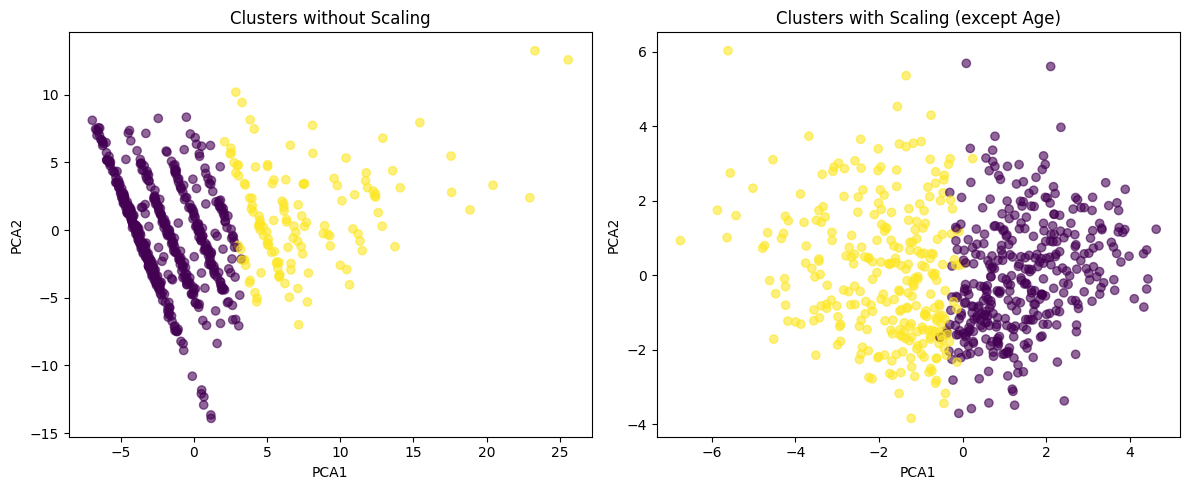


INSIGHTS:
- Without scaling, features with larger numeric ranges dominate the clustering, possibly leading to biased clusters.
- With scaling (except age), all features contribute more equally, potentially revealing different groupings.
- Compare the cluster sizes and visual separation to see the effect of scaling.


In [1]:
# ---------------------- TASK 1 ---------------------- #


import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'./py files/student-por.csv',delimiter=';')

features = df.drop(['G3'], axis=1)

features_encoded = pd.get_dummies(features, drop_first=True)

kmeans_no_scaling = KMeans(n_clusters=2, random_state=42)
clusters_no_scaling = kmeans_no_scaling.fit_predict(features_encoded)
features_encoded['Cluster_No_Scaling'] = clusters_no_scaling

cols_to_scale = [col for col in features_encoded.columns if col != 'age' and not col.startswith('Cluster')]
scaler = StandardScaler()
features_scaled = features_encoded.copy()
features_scaled[cols_to_scale] = scaler.fit_transform(features_scaled[cols_to_scale])

kmeans_scaled = KMeans(n_clusters=2, random_state=42)
clusters_scaled = kmeans_scaled.fit_predict(features_scaled.drop('Cluster_No_Scaling', axis=1))
features_scaled['Cluster_Scaled'] = clusters_scaled

comparison = pd.DataFrame({
	'No_Scaling': features_encoded['Cluster_No_Scaling'],
	'With_Scaling': features_scaled['Cluster_Scaled']
})

print('Cluster assignment counts (No Scaling):')
print(features_encoded['Cluster_No_Scaling'].value_counts())
print('\nCluster assignment counts (With Scaling):')
print(features_scaled['Cluster_Scaled'].value_counts())

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_no_scaling = pca.fit_transform(features_encoded.drop('Cluster_No_Scaling', axis=1))
reduced_scaled = pca.fit_transform(features_scaled.drop(['Cluster_No_Scaling', 'Cluster_Scaled'], axis=1))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(reduced_no_scaling[:,0], reduced_no_scaling[:,1], c=features_encoded['Cluster_No_Scaling'], cmap='viridis', alpha=0.6)
plt.title('Clusters without Scaling')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.subplot(1,2,2)
plt.scatter(reduced_scaled[:,0], reduced_scaled[:,1], c=features_scaled['Cluster_Scaled'], cmap='viridis', alpha=0.6)
plt.title('Clusters with Scaling (except Age)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("- Without scaling, features with larger numeric ranges dominate the clustering, possibly leading to biased clusters.")
print("- With scaling (except age), all features contribute more equally, potentially revealing different groupings.")
print("- Compare the cluster sizes and visual separation to see the effect of scaling.")


In [2]:
# ---------------------- TASK 2 ---------------------- #

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

data = {
	'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
	'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
	'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
	'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
	'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)
print("Original Data:")
print(df)

df_encoded = df.copy()
df_encoded['vehicle_type_encoded'] = df_encoded['vehicle_type'].map({'SUV': 0, 'Sedan': 1, 'Truck': 2, 'Hatchback': 3})

features = ['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_encoded']
X = df_encoded[features]

kmeans_no_scaling = KMeans(n_clusters=3, random_state=42)
df['Cluster_No_Scaling'] = kmeans_no_scaling.fit_predict(X)
print("\nKMeans Clustering (No Scaling):")
print(df[['vehicle_serial_no', 'vehicle_type', 'Cluster_No_Scaling']])

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['mileage', 'fuel_efficiency', 'maintenance_cost']] = scaler.fit_transform(X_scaled[['mileage', 'fuel_efficiency', 'maintenance_cost']])

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
df['Cluster_Scaled'] = kmeans_scaled.fit_predict(X_scaled)
print("\nKMeans Clustering (With Scaling):")
print(df[['vehicle_serial_no', 'vehicle_type', 'Cluster_Scaled']])

print("\nComparison of Clustering Results:")
print(df[['vehicle_serial_no', 'vehicle_type', 'Cluster_No_Scaling', 'Cluster_Scaled']])

print("\nAnalysis:")
print("- Without scaling, features with larger numeric ranges (like mileage) dominate the clustering.")
print("- With scaling, all features contribute more equally, leading to different cluster assignments.")


Original Data:
   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost vehicle_type
0                  5   150000               15              5000          SUV
1                  3   120000               18              4000        Sedan
2                  8   250000               10              7000        Truck
3                  2    80000               22              2000    Hatchback
4                  4   100000               20              3000        Sedan
5                  7   220000               12              6500        Truck
6                  6   180000               16              5500          SUV
7                 10   300000                8              8000        Truck
8                  1    75000               24              1500    Hatchback
9                  9   280000                9              7500          SUV

KMeans Clustering (No Scaling):
   vehicle_serial_no vehicle_type  Cluster_No_Scaling
0                  5          SUV       

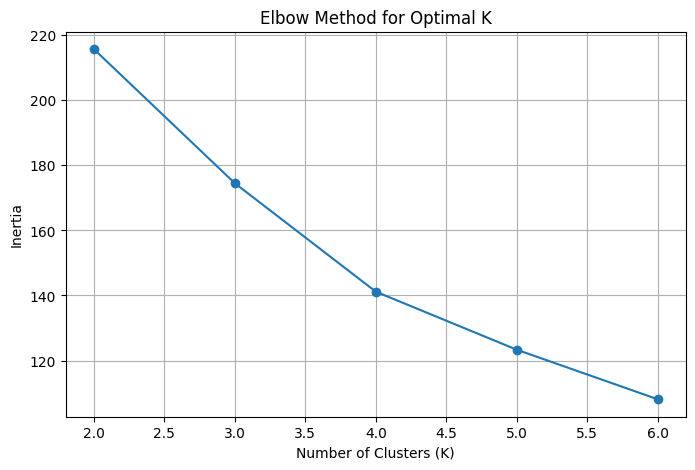

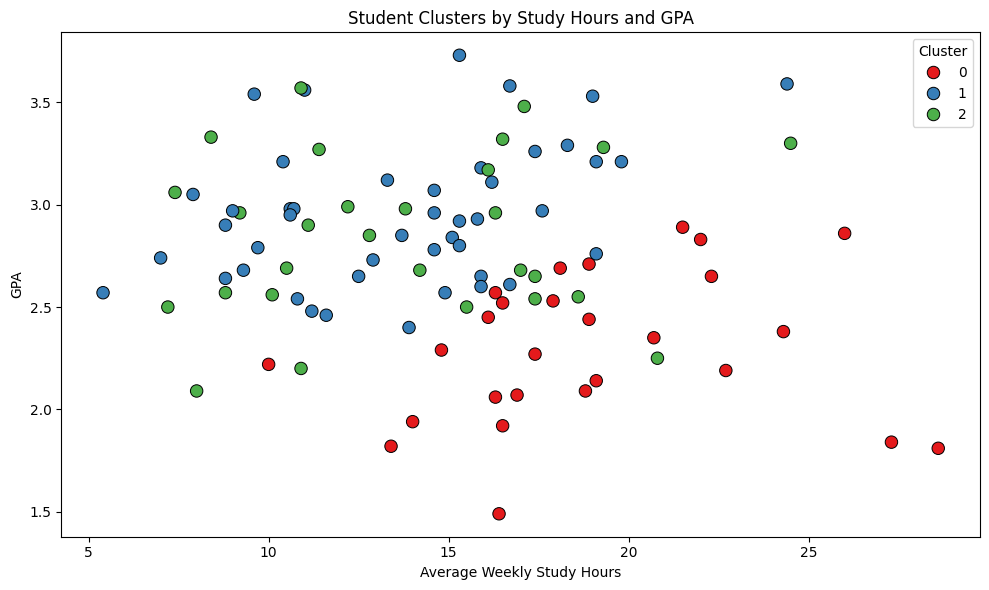

   student_id  cluster
0     STUD001        1
1     STUD002        1
2     STUD003        1
3     STUD004        1
4     STUD005        2
..        ...      ...
95    STUD096        0
96    STUD097        1
97    STUD098        1
98    STUD099        1
99    STUD100        1

[100 rows x 2 columns]


In [3]:
# ---------------------- TASK 3 ---------------------- #

# Task 3: K-Means Clustering for Student Grouping
# References: see 1_EDA_STUDENT_PERFORMANCE_.ipynb for pandas, numpy, matplotlib, seaborn, and scaling examples

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('./py files/student_cluster_data.csv')

features = ['GPA', 'study_hours', 'attendance_rate']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
k_range = range(2, 7)
for k in k_range:
	kmeans = KMeans(n_clusters=k, random_state=42)
	kmeans.fit(X_scaled)
	inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
	data=df,
	x='study_hours',
	y='GPA',
	hue='cluster',
	palette='Set1',
	s=80,
	edgecolor='k'
)
plt.title('Student Clusters by Study Hours and GPA')
plt.xlabel('Average Weekly Study Hours')
plt.ylabel('GPA')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(df[['student_id', 'cluster']])
